### 오늘의 목표
- 순환신경망을 이용하여 로이터 뉴스를 카테고리별로 분류해보자.
- 다양한 순환신경망에 대해 알아보자.

In [1]:
# 데이터 다루기 위한 라이브러리 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 데이터 가져오기(도구 불러오기)
from tensorflow.keras.datasets import reuters

In [3]:
# 데이터 가져오기(분할을 하면서 데이터 가져오기)
(X_train, y_train), (X_test, y_test) = reuters.load_data()

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8982,)
(8982,)
(2246,)
(2246,)


In [6]:
X_train

array([list([1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 16784, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 19261, 49, 2295, 13415, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 13415, 30625, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
       list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4

### 데이터 확인
- 기존의 뉴스기사 데이터와 다른 형태의 데이터
- 이 데이터는 수치 변환 및 토큰화가 이미 진행되어있는 데이터 셋
- 사전에 전처리를 이미 완료된 데이터다.
- 우리가 전처리를 처음부터 하는 것이 아닌 우리가 사용할 형태에 맞춰서 진행만 해주면 된다.
- 빈도수를 기반으로 수치화를 진행한 데이터 -> 숫자가 작을수록 많이 등장한 데이터

In [8]:
# 단어사전 확인
pd.Series(reuters.get_word_index()).sort_values()

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,0
the,1
of,2
to,3
in,4
said,5
...,...
recirculation,30975
capco,30976
figueras,30977
jung,30978


In [9]:
# 정답 종류 확인해보기
np.unique(y_train)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

### 정답 데이터 확인 결과
- 정답의 종류는 46종류 -> 다중분류
- 정답을 위한 원핫인코딩 진행을 해야한다.
- 출력층 : units : 46 / acti : softmax
- loss함수 : categorical_crossentropy


In [10]:
# 정답데이터 원핫인코딩 진행
y_train_oh = pd.get_dummies(y_train)
y_test_oh = pd.get_dummies(y_test)

In [11]:
# 문제데이터 전처리 작업 진행
# 학습 데이터를 확인하여 길이를 맞춰주기 -> timesteps 을 맞춰야 하기 때문
# 길이가 짧을 경우 패딩 0으로 채워서 확장하는 padding기법을 사용
# 길이가 너무 길 경우에는 단어를 잘라서 축소 시키기

In [13]:
# 데이터 확인
# 뉴스 문장에 적절한 길이를 찾기 위해 train 전체의 문장의 길이를 확인해보기
train_len = [] # 각 길이를 담을 리스트
for doc in X_train :
  train_len.append(len(doc))

In [15]:
# 기술 통계량 확인
pd.Series(train_len).describe()

,0
count,8982.000000
mean,145.539857
std,145.822248
min,13.000000
25%,60.000000
50%,95.000000
75%,179.000000
max,2376.000000


### 데이터의 길이 확인 결과
- 최솟값 : 13
- 최댓값 : 2376
- 평균값 : 145
- 중앙값 : 95
- 75% : 179
- 무조건 최댓값에 맞춰서 데이터를 변형시킬 경우에는 순환횟수가 너무 많아져서 학습속도가 느려지고 기엉손실이 일어나 제대로된 학습이 불가능하다.
- 따라서 데이터 별로 길이를 확인하여 적절한 값으로 맞춰서 데이터를 사용해야 한다.
- 적절한 데이터의 길이는 150~200으로 추정
- 우리는 학습을 하는데 의의를 두기 위해 120정도로 설정

In [16]:
# timestep을 120으로 설정하기
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [17]:
# 문장의 최대 길이를 120으로 설정하여 짧은 문장의 경우에는 padding을 사용하여 0으로 채우고
# 긴 문장에 대해서는 120에 맞춰서 자르기
X_train_seq = pad_sequences(X_train, maxlen = 120)
X_test_seq = pad_sequences(X_test, maxlen = 120)

In [18]:
print(X_train_seq[0])

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     1 27595 28842
     8    43    10   447     5    25   207   270     5  3095   111    16
   369   186    90    67     7    89     5    19   102     6    19   124
    15    90    67    84    22   482    26     7    48     4    49     8
   864    39   209   154     6   151     6    83    11    15    22   155
    11    15     7    48     9  4579  1005   504     6   258     6   272
    11    15    22   134    44    11    15    16     8   197  1245    90
    67    52    29   209    30    32   132     6   109    15    17    12]


In [19]:
X_train_seq.shape

(8982, 120)

In [21]:
# 순환신경망을 사용하기 위해 특성 차원을 추가하기 (차원을 늘리기)
X_train_rs = X_train_seq.reshape(8982, 120, 1) # reshape.(X_train_seq.shape[0], X_train_seq.shape[1], 1)
X_test_rs = X_test_seq.reshape(2246, 120, 1)

In [22]:
# 순환신경망을 사용하기 위한 데이터 전처리 완료
print(X_train_rs.shape)
print(X_test_rs.shape)
print(y_train_oh.shape)
print(y_test_oh.shape)

(8982, 120, 1)
(2246, 120, 1)
(8982, 46)
(2246, 46)


### 신경망 설계
- 순환신경망을 사용하기 위해 데이터셋 준비 완료
- 순환신경망을 사용해보기

In [23]:
# 도구 불러오기
from tensorflow.keras import Sequential # 뼈대 도구
from tensorflow.keras.layers import Dense, SimpleRNN, InputLayer # 신경망 층 도구

### 순환신경망
- 일반적으로 순환신경망은 다층 입력 단층 출력의 구조를 가지고 있다.
- 여러개의 순환신경망을 쌓을 때는 다층 입력 다층 출력 구조로 변경을 해줘야한다.
- return_sequences = True -> 해줘야만 다층 출력으로 구조를 변경 할 수 있다.


In [24]:
# 신경망 구축
# 뼈대 생성
model1 = Sequential()

# 입력층 쌓기
model1.add(InputLayer(shape = (120, 1))) # 입력 데이터 특성에 맞춰서 설정

# RNN 층
model1.add(SimpleRNN(units = 128, activation = 'tanh', return_sequences=True))
model1.add(SimpleRNN(units = 64, activation = 'tanh', return_sequences=True))
model1.add(SimpleRNN(units = 32, activation = 'tanh'))
# ---------------------------- RNN 층 ----------------------------------
# MLP 층 쌓기
model1.add(Dense(units=64, activation = 'relu'))

# 출력층
model1.add(Dense(units=46, activation = 'softmax'))

In [25]:
# 모델 학습방법 및 평가방법 설정
model1. compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [29]:
# 학습진행
model1.fit(
    X_train_rs, y_train_oh,
    epochs = 50,
    validation_split=0.2
    )

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 83ms/step - accuracy: 0.3517 - loss: 2.4570 - val_accuracy: 0.3645 - val_loss: 2.3746
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - accuracy: 0.3716 - loss: 2.3509 - val_accuracy: 0.3751 - val_loss: 2.3223
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.3865 - loss: 2.3003 - val_accuracy: 0.3639 - val_loss: 2.3071
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.3884 - loss: 2.2744 - val_accuracy: 0.3806 - val_loss: 2.2863
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.3930 - loss: 2.2558 - val_accuracy: 0.3834 - val_loss: 2.2648
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.4017 - loss: 2.2372 - val_accuracy: 0.3550 - val_loss: 2.3112
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.3850 - loss: 2.2857 - val_accuracy: 0.3756 - val_loss: 2.2882
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.3830 - loss: 2.2618 - 

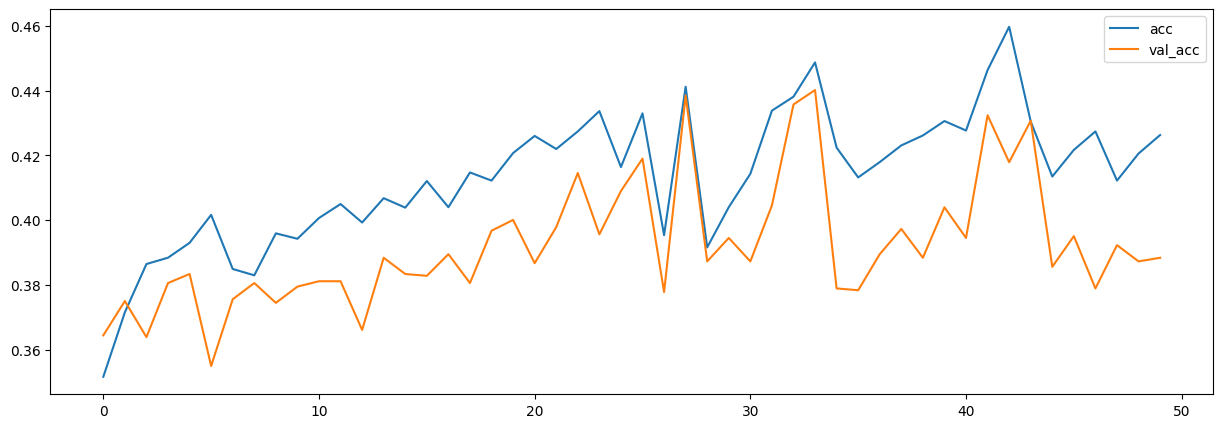

In [33]:
from prompt_toolkit.shortcuts.progress_bar.formatters import Label
# 시각화 진행
plt.figure(figsize=(15,5))
plt.plot(model1.history.history['accuracy'], label = 'acc')
plt.plot(model1.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### 결과확인
- 정확도가 향상이 되면서 학습이 진행되고 있지만 높은 편은 아니다.
### 성능을 높이는 방법
- 더 좋은 성능의 모델 사용
- 데이터 전처리 진행 (빈도기반이 아닌 의미 분석을 위한 고차원의 벡터화 방법을 사용(임베딩))
- 많은 데이터 확보
- 파라미터 값 조정 등

### RNN 모델 특성
- 기본적인 RNN 구조는 긴 시퀀스를 가지는 데이터를 효과적으로 학습하기는 어렵다.
- 문장의 길이가 엄청 길지는 않더라도, RNN성능은 조금만 길이가 길어지면 기억손실이 일어나 성능이 떨어질 가능성이 매우 높다.
- 순환횟수가 길어질 수록 초반 입력된 단어의 기억 데이터가 손실되는 현상이 발생
- 문장 구성시 초반 단어가 후반 단어에 영향을 많이 끼치는 데이터일수록 SimpleRNN의 성능은 좋지 않을 가능성이 높다.

### 단점을 보안한 모델
### LSTM(Long Shot Term Memory)
- 장기기억, 단기기억에 대해 관리계산이 추가된 모델
- 연산이 복잡해져 학습이 오래걸리고 모델이 무겁지만 기억손실이 줄어들어 성능면에서는 좋은 가능성이 높다.

In [34]:
# LSTM 불러오기
from tensorflow.keras.layers import LSTM

In [35]:
# 신경망 구현
model2 = Sequential()

# 입력층
model2.add(InputLayer(shape = (120, 1)))

# LSTM 층 쌓기
model2.add(LSTM(units = 128, activation = 'tanh', return_sequences=True))
model2.add(LSTM(units = 64, activation = 'tanh', return_sequences=True))
model2.add(LSTM(units = 32, activation = 'tanh'))
# -------------------------------MLP층 쌓기---------------------------------
model2.add(Dense(units=64, activation = 'relu'))

# 출력층
model2.add(Dense(units=46, activation = 'softmax'))

In [36]:
# 학습방법 및 평가방법 설정
model2.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [37]:
# 학습
model2.fit(
    X_train_rs, y_train_oh,
    epochs = 20,
    validation_split=0.2
    )

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 60s 245ms/step - accuracy: 0.3797 - loss: 2.4447 - val_accuracy: 0.4591 - val_loss: 2.1609
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 53s 238ms/step - accuracy: 0.4596 - loss: 2.1333 - val_accuracy: 0.4485 - val_loss: 2.0979
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 53s 237ms/step - accuracy: 0.4647 - loss: 2.1060 - val_accuracy: 0.4624 - val_loss: 2.0712
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 53s 237ms/step - accuracy: 0.4660 - loss: 2.0818 - val_accuracy: 0.4580 - val_loss: 2.0594
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 55s 244ms/step - accuracy: 0.4715 - loss: 2.0496 - val_accuracy: 0.4741 - val_loss: 2.0331
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 53s 237ms/step - accuracy: 0.4724 - loss: 2.0336 - val_accuracy: 0.4758 - val_loss: 2.0256
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 54s 239ms/step - accuracy: 0.4718 - loss: 2.0184 - val_accuracy: 0.4802 - val_loss: 2.0220
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 54s 241ms/step - accuracy: 0.4782 - loss: 1

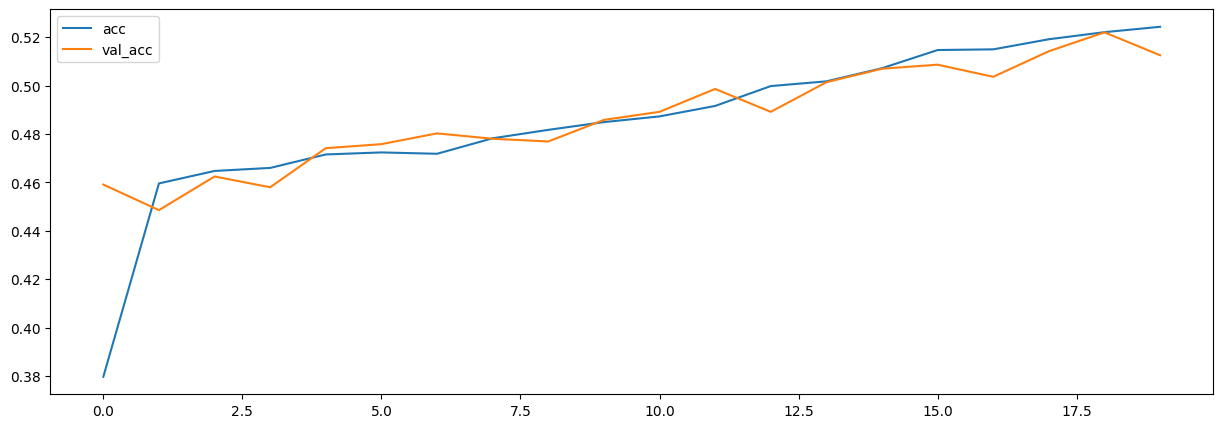

In [38]:
# 시각화 진행
plt.figure(figsize=(15,5))
plt.plot(model2.history.history['accuracy'], label = 'acc')
plt.plot(model2.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()